In [1]:
#This cell contains libraries that are included

In [1]:
import sys
sys.executable
import requests
import pandas as pd
import os
import matplotlib.pyplot as plt

/Users/wizard/cf_analyzer/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def fetch_submissions(handle, limit=1000):
    url = f"https://codeforces.com/api/user.status?handle={handle}&count={limit}"
    response = requests.get(url, timeout=10)

    if response.status_code != 200:
        raise Exception("Network error")

    data = response.json()

    if data["status"] != "OK":
        raise Exception("Invalid Codeforces handle")

    return data["result"]

In [3]:
def save_to_csv(handle, submissions):
    rows = []

    for sub in submissions:
        row = {
            "handle": handle,
            "problem_name": sub["problem"]["name"],
            "contest_id": sub.get("contestId"),
            "problem_index": sub["problem"]["index"],
            "verdict": sub.get("verdict"),
            "language": sub.get("programmingLanguage"),
            "time_ms": sub.get("timeConsumedMillis"),
            "memory_kb": sub.get("memoryConsumedBytes", 0) // 1024,
            "timestamp": sub.get("creationTimeSeconds")
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    os.makedirs("data", exist_ok=True)
    file_path = f"data/{handle}_submissions.csv"
    df.to_csv(file_path, index=False)

    return file_path

In [38]:
handle = input("Enter Codeforces handle: ")

submissions = fetch_submissions(handle)
csv_file = save_to_csv(handle, submissions)

print("Total submissions:", len(submissions))
print("Saved to:", csv_file)

Enter Codeforces handle:  cp_wiz


Total submissions: 465
Saved to: data/cp_wiz_submissions.csv


In [39]:
df = pd.read_csv(csv_file)
df.head()


,handle,problem_name,contest_id,problem_index,verdict,language,time_ms,memory_kb,timestamp
0,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10400,1769201871
1,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10300,1769201747
2,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",31,100,1769184307
3,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",46,0,1769184092
4,cp_wiz,Table with Numbers,2189,A,OK,"C++23 (GCC 14-64, msys2)",46,100,1769180763


In [40]:

handle = input("Enter handle again (for CSV load): ")
csv_file = f"data/{handle}_submissions.csv"

df = pd.read_csv(csv_file)
df.head()

Enter handle again (for CSV load):  cp_wiz


,handle,problem_name,contest_id,problem_index,verdict,language,time_ms,memory_kb,timestamp
0,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10400,1769201871
1,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10300,1769201747
2,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",31,100,1769184307
3,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",46,0,1769184092
4,cp_wiz,Table with Numbers,2189,A,OK,"C++23 (GCC 14-64, msys2)",46,100,1769180763


In [41]:
print("Total submissions:", len(df))
print("Unique problems tried:", df[["contest_id","problem_index"]].drop_duplicates().shape[0])
print("Languages used:", df["language"].nunique())

Total submissions: 465
Unique problems tried: 270
Languages used: 4


In [42]:
verdict_count = df["verdict"].value_counts()
verdict_count

verdict
OK                       283
WRONG_ANSWER             150
COMPILATION_ERROR         18
TIME_LIMIT_EXCEEDED       10
RUNTIME_ERROR              3
MEMORY_LIMIT_EXCEEDED      1
Name: count, dtype: int64

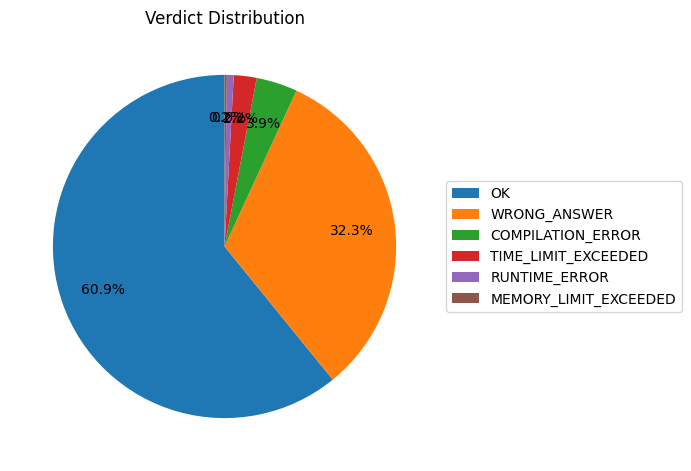

In [43]:
plt.figure(figsize=(7,7))

verdict_count.plot(
    kind="pie",
    labels=None,          # 🔴 labels বন্ধ
    autopct="%1.1f%%",    # ✅ শুধু percentage
    startangle=90,
    pctdistance=0.75      # percentage একটু ভেতরে
)

plt.title("Verdict Distribution")
plt.ylabel("")

plt.legend(
    verdict_count.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [44]:
language_count = df["language"].value_counts()
language_count

language
C++23 (GCC 14-64, msys2)    307
GNU C11                     101
C++17 (GCC 7-32)             40
C++20 (GCC 13-64)            17
Name: count, dtype: int64

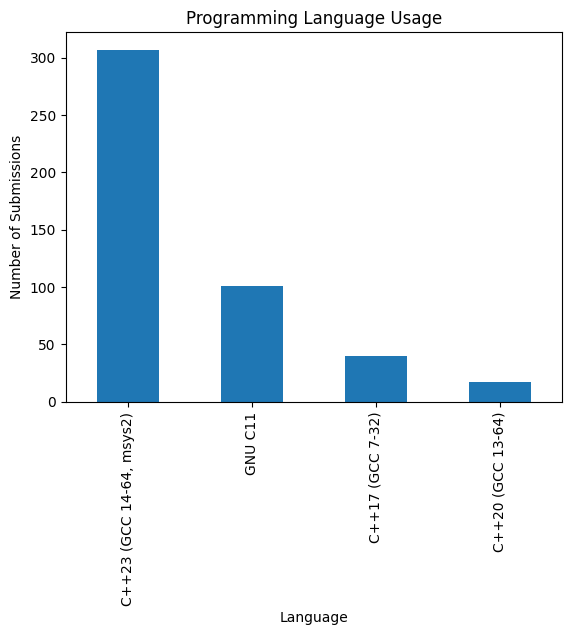

In [45]:
plt.figure()
language_count.plot(kind="bar")
plt.title("Programming Language Usage")
plt.xlabel("Language")
plt.ylabel("Number of Submissions")
plt.show()

In [46]:
tried = df[["contest_id","problem_index"]].drop_duplicates()
solved = df[df["verdict"]=="OK"][["contest_id","problem_index"]].drop_duplicates()

print("Problems Tried:", len(tried))
print("Problems Solved:", len(solved))

Problems Tried: 270
Problems Solved: 257


In [47]:
def extract_rating(sub):
    return sub.get("problem", {}).get("rating")

# Reload raw submissions to get rating
submissions = fetch_submissions(handle)

ratings = []
for sub in submissions:
    ratings.append(sub.get("problem", {}).get("rating"))

df["rating"] = ratings
df.head()

,handle,problem_name,contest_id,problem_index,verdict,language,time_ms,memory_kb,timestamp,rating
0,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10400,1769201871,1500.0
1,cp_wiz,k-Multiple Free Set,274,A,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",406,10300,1769201747,1500.0
2,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",31,100,1769184307,NaN
3,cp_wiz,The Curse of the Frog,2189,B,WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",46,0,1769184092,NaN
4,cp_wiz,Table with Numbers,2189,A,OK,"C++23 (GCC 14-64, msys2)",46,100,1769180763,NaN


In [48]:
rating_count = df["rating"].value_counts().sort_index()
rating_count

rating
800.0     247
900.0      95
1000.0     56
1100.0      3
1200.0      7
1300.0      3
1400.0      1
1500.0      2
1900.0      1
Name: count, dtype: int64

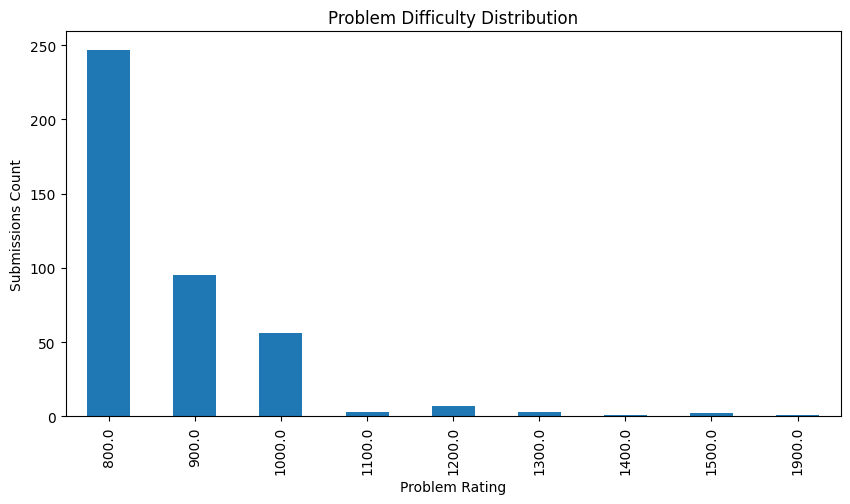

In [49]:
plt.figure(figsize=(10,5))
rating_count.plot(kind="bar")
plt.title("Problem Difficulty Distribution")
plt.xlabel("Problem Rating")
plt.ylabel("Submissions Count")
plt.show()

In [50]:
def extract_tags(sub):
    return sub.get("problem", {}).get("tags", [])

tags = []
for sub in submissions:
    tags.extend(extract_tags(sub))

tags_df = pd.Series(tags)
tags_df.head()


0    binary search
1           greedy
2         sortings
3    binary search
4           greedy
dtype: object

In [51]:
tag_count = tags_df.value_counts()
tag_count.head(12)

implementation             205
math                       201
greedy                     139
brute force                 80
constructive algorithms     76
strings                     53
sortings                    45
number theory               41
dp                          18
binary search               12
data structures             10
bitmasks                    10
Name: count, dtype: int64

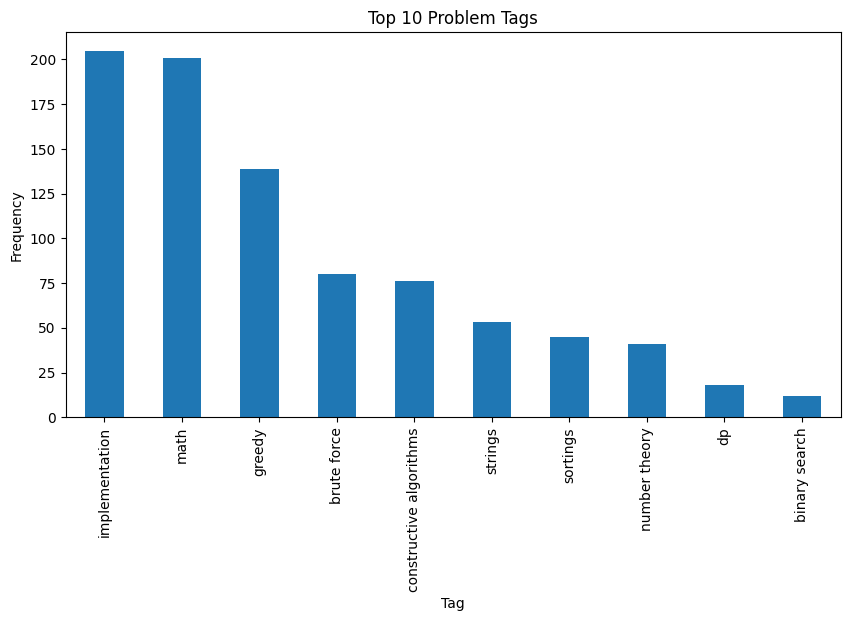

In [52]:
plt.figure(figsize=(10,5))
tag_count.head(10).plot(kind="bar")
plt.title("Top 10 Problem Tags")
plt.xlabel("Tag")
plt.ylabel("Frequency")
plt.show()

In [53]:
weak_tags = []

for tag in tag_count.index:
    total = 0
    solved = 0
    
    for sub in submissions:
        if tag in sub.get("problem", {}).get("tags", []):
            total += 1
            if sub.get("verdict") == "OK":
                solved += 1
    
    if total > 5 and solved / total < 0.4:
        weak_tags.append((tag, solved, total))

weak_tags

[('binary search', 3, 12), ('dfs and similar', 3, 8), ('graphs', 2, 7)]

In [54]:
import pandas as pd

phase4_rows = []

for tag in tag_count.index:
    total = 0
    solved = 0

    for sub in submissions:
        problem = sub.get("problem", {})
        tags = problem.get("tags", [])

        if tag in tags:
            total += 1
            if sub.get("verdict") == "OK":
                solved += 1

    if total >= 5:  # minimum attempts condition
        ac_ratio = solved / total
        if ac_ratio < 0.4:
            phase4_rows.append({
                "Tag": tag,
                "Attempts": total,
                "Solved": solved,
                "AC_Ratio": round(ac_ratio, 2)
            })

weak_df = pd.DataFrame(phase4_rows)
weak_df["Practice_Link"] = weak_df["Tag"].apply(
    lambda t: f"https://codeforces.com/problemset?tags={t}"
)

weak_df

,Tag,Attempts,Solved,AC_Ratio,Practice_Link
0,binary search,12,3,0.25,https://codeforces.com/problemset?tags=binary ...
1,dfs and similar,8,3,0.38,https://codeforces.com/problemset?tags=dfs and...
2,graphs,7,2,0.29,https://codeforces.com/problemset?tags=graphs


In [55]:
from collections import defaultdict

wa_count = defaultdict(int)
tle_count = defaultdict(int)

for sub in submissions:
    verdict = sub.get("verdict")
    tags = sub.get("problem", {}).get("tags", [])

    for tag in tags:
        if verdict == "WRONG_ANSWER":
            wa_count[tag] += 1
        elif verdict == "TIME_LIMIT_EXCEEDED":
            tle_count[tag] += 1

In [56]:
wa_df = pd.DataFrame(wa_count.items(), columns=["Tag", "WA_Count"])
tle_df = pd.DataFrame(tle_count.items(), columns=["Tag", "TLE_Count"])

wa_df = wa_df.sort_values("WA_Count", ascending=False)
tle_df = tle_df.sort_values("TLE_Count", ascending=False)

wa_df.head(10), tle_df.head(10)

(                        Tag  WA_Count
 3                      math        78
 4            implementation        58
 1                    greedy        46
 7   constructive algorithms        33
 5               brute force        24
 12                  strings        17
 6             number theory        17
 2                  sortings        13
 0             binary search         6
 9                        dp         6,
                Tag  TLE_Count
 1   implementation          8
 2             math          5
 4           greedy          5
 0  data structures          4
 7      brute force          4
 3     two pointers          3
 6    binary search          3
 5               dp          1)

<Figure size 1000x500 with 0 Axes>

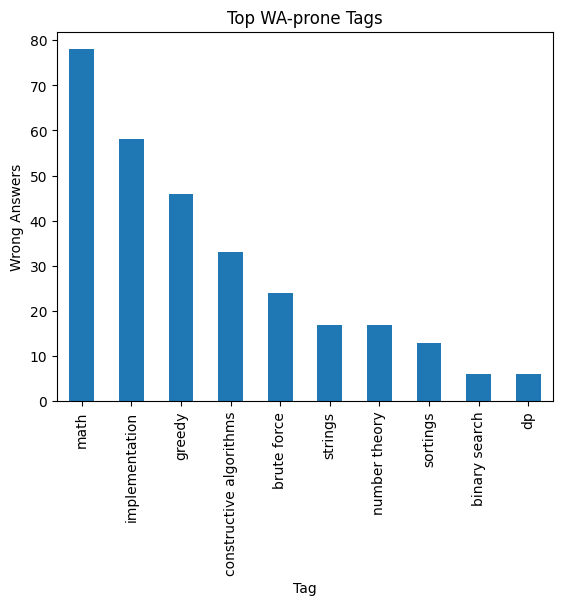

In [57]:
plt.figure(figsize=(10,5))
wa_df.head(10).plot(x="Tag", y="WA_Count", kind="bar", legend=False)
plt.title("Top WA-prone Tags")
plt.ylabel("Wrong Answers")
plt.show()

<Figure size 1000x500 with 0 Axes>

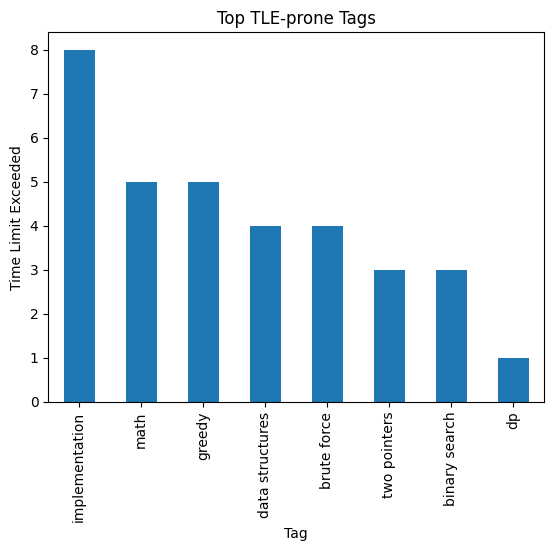

In [58]:
plt.figure(figsize=(10,5))
tle_df.head(10).plot(x="Tag", y="TLE_Count", kind="bar", legend=False)
plt.title("Top TLE-prone Tags")
plt.ylabel("Time Limit Exceeded")
plt.show()